In [1]:
#01 try


[INFO] 使用数据自身的 q 窗口: [4.569, 4.685] Å^-1
MAP: I0=0.4745, a=5.430000 Å, mu=7.753621e-06, aS=5.433517 Å, NS=129205


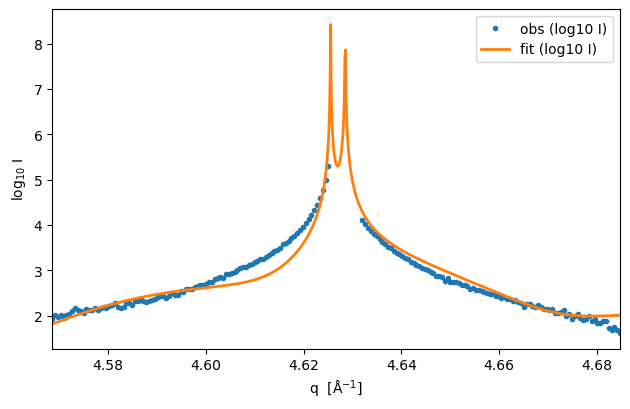

In [2]:
# -*- coding: utf-8 -*-
# CTRmodel04: robust read (CP932/Shift-JIS), convert 2θ→q, fit over data-driven q window
# 5-parameter structure but fix a=5.43 Å and μ=1/128972 as requested.

import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== 0) 路径 & 全局设置 =====================
FILE_NAME = "data-2025-0822by akai/Si_TEOS_2thome.dat"   # 数据文件与本 .py 同目录
E_KEV = 8.0                      # X-ray energy for 2θ→q
REMOVE_BRAGG_NEAR = True         # 剔除 sin(qa/2)=0 附近的点
DQ_BRAGG = 0.003                 # 剔除窗口 ±dq [Å^-1]

try:
    ROOT = Path(__file__).resolve().parent
except NameError:               # 在交互/Notebook中运行
    ROOT = Path.cwd()
MEAS_PATH = ROOT / FILE_NAME

# 物理设定
N_SIM = 128_972
a_fixed = 5.43e-4 * 1e4         # 5.43×10^-4 μm = 5.43 Å
mu_fixed = 1.0 / N_SIM
log10mu_fixed = np.log10(mu_fixed)

# ===================== 1) 读取器：表头+"Axis (deg), I (cts)" =====================
def read_axis_I_cp932_first(path: Path):
    """
    从包含 'Axis (deg), I (cts)' 表头的文件读取两列：
      2θ[deg], I[counts]
    优先用 CP932（Shift-JIS），失败时回退到 utf-8 / latin1。
    """
    tried = []
    for enc in ("cp932", "shift_jis", "utf-8", "utf-8-sig", "latin1"):
        tried.append(enc)
        try:
            txt = path.read_text(encoding=enc, errors="strict")
            break
        except Exception:
            txt = None
    if txt is None:
        # 最后强制忽略错误
        txt = path.read_text(encoding="latin1", errors="ignore")

    lines = txt.splitlines()
    start = None
    for i, ln in enumerate(lines):
        if "Axis" in ln and "I" in ln:
            start = i + 1
            break
    if start is None:
        # 兜底：无表头时，尝试逐行两列数字解析
        return load_qI_fallback(path)

    two_theta, inten = [], []
    for ln in lines[start:]:
        # 允许逗号/空格/Tab混合
        parts = re.split(r"[,\s]+", ln.strip())
        parts = [p for p in parts if p]
        if len(parts) < 2:
            continue
        try:
            two_theta.append(float(parts[0]))
            inten.append(float(parts[1]))
        except ValueError:
            continue
    if not two_theta:
        # 若表头下无数据，退回通用解析
        return load_qI_fallback(path)
    return np.asarray(two_theta, float), np.asarray(inten, float)

def load_qI_fallback(path: Path):
    """通用两列解析（不依赖表头），用于兜底。"""
    # 宽松读取
    txt = path.read_text(encoding="latin1", errors="ignore")
    xs, ys = [], []
    num_pat = re.compile(r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?")
    for ln in txt.splitlines():
        # 去常见注释
        for m in ("//", "#", ";", "!", "%", "＊"):
            pos = ln.find(m)
            if pos >= 0:
                ln = ln[:pos]
        ln = ln.replace(",", " ").replace("\t", " ")
        nums = num_pat.findall(ln)
        if len(nums) >= 2:
            try:
                xs.append(float(nums[0])); ys.append(float(nums[1]))
            except ValueError:
                pass
    if not xs:
        raise ValueError(f"无法从 {path} 解析两列数值。")
    return np.asarray(xs, float), np.asarray(ys, float)

# 2θ→q（Å^-1）
def twotheta_to_q(two_theta_deg, E_keV=E_KEV):
    lam = 12.3984193 / E_keV   # Å
    theta = np.deg2rad(two_theta_deg / 2.0)
    return 4.0*np.pi*np.sin(theta) / lam

two_theta_deg, I_raw = read_axis_I_cp932_first(MEAS_PATH)
q_all = twotheta_to_q(two_theta_deg, E_keV=E_KEV)

# 选择“合适的窗口”：直接使用数据的 q 范围（避免误裁剪）
QMIN = float(np.min(q_all))
QMAX = float(np.max(q_all))
print(f"[INFO] 使用数据自身的 q 窗口: [{QMIN:.3f}, {QMAX:.3f}] Å^-1")

# 剔除 Bragg 奇点附近（可关）
def mask_bragg(q, a, dq=DQ_BRAGG):
    mask = np.ones_like(q, dtype=bool)
    m_min = int(np.floor(QMIN * a / (2*np.pi)))
    m_max = int(np.ceil (QMAX * a / (2*np.pi)))
    for m in range(max(1, m_min), m_max+1):
        q0 = 2*np.pi*m / a
        mask &= (np.abs(q - q0) > dq)
    return mask

sel_window = (q_all >= QMIN) & (q_all <= QMAX)
if REMOVE_BRAGG_NEAR:
    sel_window &= mask_bragg(q_all, a_fixed, dq=DQ_BRAGG)

q = q_all[sel_window]
y = np.log10(np.maximum(I_raw[sel_window], 1e-30))   # 在 log10(I) 域拟合

# ===================== 2) CTR4 模型（闭式和，返回 log10 I） =====================
_EPS_ = 1e-12

def CTR4_log10I_closed(q, I0, a, mu, aS, NS):
    """
    I(q) = 10^{I0} * | Σ_{n=0}^{NS-1} e^{-n μ} e^{i q aS n} + 1/(√2 sin(qa/2)) |^2
    用几何级数闭式：S = (1 - r^{NS}) / (1 - r), r = e^{-μ + iqaS}
    返回 log10 I(q)
    """
    NSi = max(1, int(np.round(NS)))
    r   = np.exp(-mu + 1j*q*aS)
    den = 1.0 - r
    rpow = np.exp(NSi * (-mu + 1j*q*aS))
    S = (1.0 - rpow) / den
    near = np.abs(den) < 1e-10
    if np.any(near):
        S = np.where(near, NSi*np.ones_like(q, dtype=np.complex128), S)

    sin_term = np.sin(0.5*q*a)
    sin_term = np.where(np.abs(sin_term) < _EPS_, np.sign(sin_term)*_EPS_, sin_term)
    S = S + 1.0/(np.sqrt(2.0)*sin_term)

    return I0 + 2.0*np.log10(np.maximum(np.abs(S), 1e-300))

def fwd(q, p):
    I0, a, log10mu, aS, NS = p
    mu = 10.0**log10mu
    return CTR4_log10I_closed(q, I0, a, mu, aS, NS)

# ===================== 3) 后验（均匀先验 + 高斯似然） =====================
param_names = ['I0','a','log10mu','aS','NS']
# 固定 a、μ：上下界相等 + 步长=0
p_min = np.array([-6.0, a_fixed, log10mu_fixed, 5.30,           1.0 ])
p_max = np.array([+6.0, a_fixed, log10mu_fixed, 5.55,      300000.0 ])
steps = np.array([0.02, 0.0,      0.0,           0.002,     500.0   ])
sigma_R = 0.05

def log_prior(p):
    return 0.0 if np.all(p >= p_min) and np.all(p <= p_max) else -np.inf

def log_like(p):
    yhat = fwd(q, p)
    r = y - yhat
    return -0.5*np.sum((r/sigma_R)**2) - len(y)*np.log(sigma_R*np.sqrt(2*np.pi))

def log_post(p):
    lp = log_prior(p)
    return -np.inf if not np.isfinite(lp) else lp + log_like(p)

# ===================== 4) Metropolis-Hastings（逐参数更新，NS 取整） =====================
rng = np.random.default_rng(42)
p    = np.array([0.0, a_fixed, log10mu_fixed, 5.431, float(N_SIM)])  # 初值
lp   = log_post(p)

n_steps = N_SIM
burn, thin = 20000, 10
acc = np.zeros(len(param_names), dtype=int)
trace = []

for t in range(n_steps):
    for k in range(len(param_names)):
        if steps[k] == 0.0:
            continue
        prop = p.copy()
        prop[k] += rng.normal(0.0, steps[k])
        if param_names[k] == 'NS':
            prop[k] = np.round(prop[k])
        prop[k] = np.clip(prop[k], p_min[k], p_max[k])

        lp_prop = log_post(prop)
        if np.log(rng.random()) < (lp_prop - lp):
            p, lp = prop, lp_prop
            acc[k] += 1

    if t >= burn and ((t - burn) % thin == 0):
        trace.append(p.copy())

trace = np.array(trace)

# ===================== 5) MAP 与对比绘图 =====================
def map_estimate(samples):
    lps = np.array([log_post(s) for s in samples])
    return samples[np.argmax(lps)]

p_map = map_estimate(trace)
I0_m, a_m, lmu_m, aS_m, NS_m = p_map
print(f"MAP: I0={I0_m:.4f}, a={a_m:.6f} Å, mu={10**lmu_m:.6e}, "
      f"aS={aS_m:.6f} Å, NS={int(round(NS_m))}")

# 平滑曲
q_plot = np.linspace(QMIN, QMAX, 1000)
yhat_plot = fwd(q_plot, p_map)

plt.figure(figsize=(6.4, 4.2))
plt.plot(q, y, "o", ms=3, label="obs (log10 I)")
plt.plot(q_plot, yhat_plot, "-", lw=2, label="fit (log10 I)")
plt.xlim(QMIN, QMAX)
plt.xlabel(r"q  [$\mathrm{\AA^{-1}}$]")
plt.ylabel(r"log$_{10}$ I")
plt.legend()
plt.tight_layout()
plt.show()
